In [1]:
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re

E0000 00:00:1774515035.254559    6267 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774515035.295871    6267 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1774515035.590083    6267 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774515035.590188    6267 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774515035.590190    6267 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774515035.590192    6267 computation_placer.cc:177] computation placer already registered. Please check linka

In [120]:
df = pd.read_csv('dataset/final_3_cleaned.csv')

In [121]:
df.head()

,sentence,sentiment
0,SpiceJet to issue 6.4 crore warrants to promoters,neutral
1,MMTC Q2 net loss at Rs 10.4 crore,neutral
2,"""Mid-cap funds can deliver more, stay put: Exp...",positive
3,Mid caps now turn into market darlings,positive
4,"""Market seeing patience, if not conviction: Pr...",neutral


In [122]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+", " ", text)   # remove urls
    text = re.sub(r"\S+@\S+", " ", text)          # remove emails
    text = re.sub(r"<.*?>", " ", text)            # remove html tags
    text = re.sub(r"\s+", " ", text).strip()      # remove extra spaces
    return text

df["sentence"] = df["sentence"].astype(str)
df["sentence_clean"] = df["sentence"].apply(clean_text)

In [ ]:
# label_counts = df.groupby("sentence_clean")["sentiment"].nunique()
# conflicting = label_counts[label_counts > 1].index

# df = df[~df["sentence_clean"].isin(conflicting)].copy()
# df = df.drop_duplicates(subset=["sentence_clean"]).reset_index(drop=True)

# print(df["sentiment"].value_counts())
# print(df.shape)

In [123]:
map = {'neutral': 0, 'positive': 1, 'negative': 2}
df['sentiment'] = df['sentiment'].map(map)
df.head()

,sentence,sentiment,sentence_clean
0,SpiceJet to issue 6.4 crore warrants to promoters,0,spicejet to issue 6.4 crore warrants to promoters
1,MMTC Q2 net loss at Rs 10.4 crore,0,mmtc q2 net loss at rs 10.4 crore
2,"""Mid-cap funds can deliver more, stay put: Exp...",1,"""mid-cap funds can deliver more, stay put: exp..."
3,Mid caps now turn into market darlings,1,mid caps now turn into market darlings
4,"""Market seeing patience, if not conviction: Pr...",0,"""market seeing patience, if not conviction: pr..."


In [124]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['sentiment'] = le.fit_transform(df['sentiment'])
df.head()

,sentence,sentiment,sentence_clean
0,SpiceJet to issue 6.4 crore warrants to promoters,0,spicejet to issue 6.4 crore warrants to promoters
1,MMTC Q2 net loss at Rs 10.4 crore,0,mmtc q2 net loss at rs 10.4 crore
2,"""Mid-cap funds can deliver more, stay put: Exp...",1,"""mid-cap funds can deliver more, stay put: exp..."
3,Mid caps now turn into market darlings,1,mid caps now turn into market darlings
4,"""Market seeing patience, if not conviction: Pr...",0,"""market seeing patience, if not conviction: pr..."


In [125]:
from sklearn.model_selection import train_test_split

X = df['sentence_clean']
y = df['sentiment']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [126]:
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train,
    test_size=0.1,
    random_state=42,
    stratify=y_train
)

In [211]:
max_tokens = 12000
sequence_length = 40

text_vectorizer = tf.keras.layers.TextVectorization(
    max_tokens=max_tokens,
    output_mode="int",
    output_sequence_length=sequence_length,
    standardize="lower_and_strip_punctuation"  
)

# adapt only on training text
text_vectorizer.adapt(X_train)

vocab_size = len(text_vectorizer.get_vocabulary())
print("Vocab size:", vocab_size)

Vocab size: 12000


In [212]:
batch_size = 32

train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train))
val_ds = tf.data.Dataset.from_tensor_slices((X_val, y_val))
test_ds = tf.data.Dataset.from_tensor_slices((X_test, y_test))

train_ds = train_ds.shuffle(len(X_train)).batch(batch_size).prefetch(tf.data.AUTOTUNE)
val_ds = val_ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
test_ds = test_ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)

In [213]:
from sklearn.utils.class_weight import compute_class_weight

classes = np.unique(y_train)
weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)
class_weight = dict(zip(classes, weights))

print("Class weights:", class_weight)


Class weights: {np.int64(0): np.float64(0.9426229508196722), np.int64(1): np.float64(0.9114927344782034), np.int64(2): np.float64(1.1876075731497417)}


In [215]:
model = tf.keras.models.Sequential([
    tf.keras.layers.Input(shape=(1,), dtype=tf.string),

    text_vectorizer,

    tf.keras.layers.Embedding(
        input_dim=vocab_size,
        output_dim=16,
        mask_zero=True
    ),
    tf.keras.layers.SpatialDropout1D(0.2),
    tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(24,
                                                    kernel_regularizer=tf.keras.regularizers.l2(0.01),)),
    tf.keras.layers.Dropout(0.2),

    # tf.keras.layers.Bidirectional(tf.keras.layers.LSTM(4)),
    #tf.keras.layers.Dropout(0.2),

    tf.keras.layers.Dense(16, activation="relu"),
    tf.keras.layers.Dropout(0.2),

    tf.keras.layers.Dense(3, activation="softmax")
])

In [216]:
model.summary()

Model: "sequential_25"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ text_vectorization_23           │ (None, 40)             │             0 │
│ (TextVectorization)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_25 (Embedding)        │ (None, 40, 16)         │       192,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_2             │ (None, 40, 16)         │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_25                │ (None, 48)             │         7,872 │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 48)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_50 (Dense)                │ (None, 16)             │           784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_51 (Dense)                │ (None, 3)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 200,707 (784.01 KB)

 Trainable params: 200,707 (784.01 KB)

 Non-trainable params: 0 (0.00 B)

In [217]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [219]:
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_accuracy",
    patience=5,
    restore_best_weights=True
)

mc = tf.keras.callbacks.ModelCheckpoint(
    filepath="models/sentiment.keras",
    monitor="val_accuracy",
    mode="max",
    save_best_only=True,
    save_weights_only=False,
    verbose=1
),

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_accuracy",
    factor=0.5,
    patience=2
)

In [220]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    class_weight=class_weight,
    batch_size=batch_size,
    callbacks=[early_stopping, mc, reduce_lr])

Epoch 1/20


257/259 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step - accuracy: 0.4001 - loss: 1.3574
Epoch 1: val_accuracy improved from None to 0.56413, saving model to models/sentiment.keras
259/259 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step - accuracy: 0.4581 - loss: 1.1684 - val_accuracy: 0.5641 - val_loss: 0.8908 - learning_rate: 0.0010
Epoch 2/20
240/259 ━━━━━━━━━━━━━━━━━━━━ 2s 117ms/step - accuracy: 0.6338 - loss: 0.7912
Epoch 2: val_accuracy improved from 0.56413 to 0.73370, saving model to models/sentiment.keras
259/259 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - accuracy: 0.6854 - loss: 0.7497 - val_accuracy: 0.7337 - val_loss: 0.7132 - learning_rate: 0.0010
Epoch 3/20
244/259 ━━━━━━━━━━━━━━━━━━━━ 1s 115ms/step - accuracy: 0.8477 - loss: 0.4855
Epoch 3: val_accuracy improved from 0.73370 to 0.76304, saving model to models/sentiment.keras
259/259 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - accuracy: 0.8500 - loss: 0.4656 - val_accuracy: 0.7630 - val_loss: 0.6684 - learning_rate: 0.0010
Epoch 4/20
238/259 ━━━━━━━━━━━━━━━━━━━━

In [221]:
eval = model.evaluate(test_ds, batch_size=batch_size, verbose=1)
print("Test loss:", eval[0])
print("Test accuracy:", eval[1])

 1/72 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.8125 - loss: 0.5454

72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.7761 - loss: 0.6451
Test loss: 0.6451252698898315
Test accuracy: 0.7760869860649109


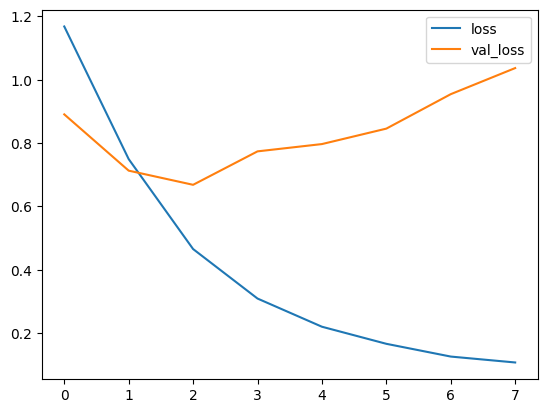

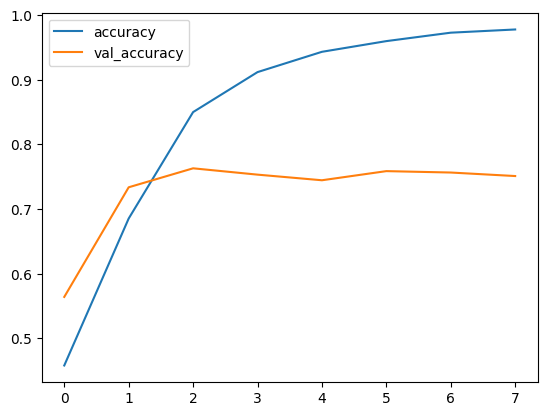

In [222]:
history = pd.DataFrame(history.history)

history[["loss", "val_loss"]].plot()
history[["accuracy", "val_accuracy"]].plot()
plt.show()

In [223]:
from sklearn.metrics import classification_report
y_pred = model.predict(test_ds)
print(classification_report(y_test, np.argmax(y_pred, axis=1)))

72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step
              precision    recall  f1-score   support

           0       0.77      0.77      0.77       827
           1       0.76      0.80      0.78       853
           2       0.81      0.75      0.78       620

    accuracy                           0.78      2300
   macro avg       0.78      0.77      0.78      2300
weighted avg       0.78      0.78      0.78      2300



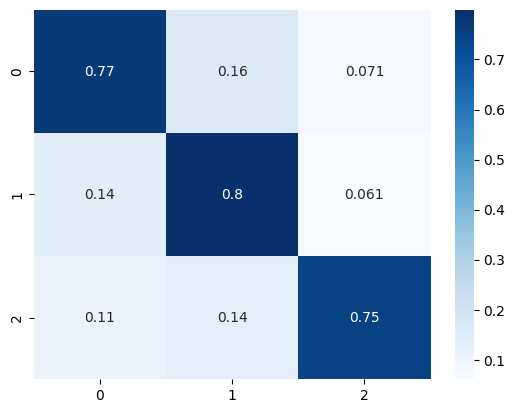

In [224]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, np.argmax(y_pred, axis=1))
cm = cm.astype("float") / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm, annot=True, cmap="Blues")
plt.show()

In [225]:
test_texts = [
    # Positive (Class 1)
    "The company reported strong quarterly earnings driven by increased demand and improved operational efficiency.",
    "The firm announced a major investment in renewable energy projects, boosting investor confidence.",
    "Revenue growth exceeded expectations, supported by expansion into new markets.",
    "The company's sustainability initiatives have significantly improved its ESG rating.",
    "The acquisition is expected to strengthen the company's market position and increase profitability.",
    "The company's improved governance structure strengthened investor confidence.",

    # Negative (Class 2)
    "The company reported significant losses due to declining sales and rising operational costs.",
    "The firm faces regulatory scrutiny over environmental violations.",
    "Revenue dropped sharply following weaker demand and supply chain disruptions.",
    "The company downgraded its earnings forecast due to market uncertainty.",
    "Investors expressed concerns about governance issues and declining margins.",
    "The firm's carbon emissions increased, raising concerns among stakeholders.",

    # Neutral (Class 0)
    "The company announced its quarterly financial results for the fiscal year.",
    "The board approved the annual sustainability report.",
    "The firm expanded its operations into Southeast Asia.",
    "The company held its annual shareholder meeting yesterday.",
    "The organization published its ESG disclosure report for 2024.",
    "The company updated its ESG reporting framework.",

    # Hard / Edge Cases
    "The company reported stable earnings despite market volatility.",
    "The firm maintained its previous ESG score.",
    "The company expects moderate growth in the coming quarters."
]

In [226]:
test_tensor = tf.constant(test_texts, dtype=tf.string)

pred = model.predict(test_tensor)
pred_classes = np.argmax(pred, axis=1)
pred_labels = le.inverse_transform(pred_classes)
reverse_map = {0: 'neutral', 1: 'positive', 2: 'negative'}

for text, label in zip(test_texts, pred_labels):
    print(f"{reverse_map[label]} -> {text}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 208ms/step
positive -> The company reported strong quarterly earnings driven by increased demand and improved operational efficiency.
positive -> The firm announced a major investment in renewable energy projects, boosting investor confidence.
positive -> Revenue growth exceeded expectations, supported by expansion into new markets.
positive -> The company's sustainability initiatives have significantly improved its ESG rating.
positive -> The acquisition is expected to strengthen the company's market position and increase profitability.
positive -> The company's improved governance structure strengthened investor confidence.
negative -> The company reported significant losses due to declining sales and rising operational costs.
negative -> The firm faces regulatory scrutiny over environmental violations.
negative -> Revenue dropped sharply following weaker demand and supply chain disruptions.
negative -> The company downgraded its earnings forecast due to m